# Ocupacion de camillas hospitalarias
## Pregunta de negocio: que pabellon se queda sin camillas este turno?

Analisis exploratorio con pandas para identificar cuellos de botella de capacidad y anticipar la campana de invierno.

**Autor:** Pablo Morales | **Datos:** sinteticos (no representan pacientes reales)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.max_columns", None)

## 1. Cargar y explorar los datos

In [2]:
df = pd.read_csv("data/ocupacion_camillas.csv", parse_dates=["fecha"])
print(f"Filas: {len(df):,} | Rango: {df.fecha.min().date()} a {df.fecha.max().date()}")
df.head()

Filas: 26,280 | Rango: 2025-08-19 a 2026-08-18


,fecha,hospital,servicio,turno,camillas_totales,camillas_ocupadas,tasa_ocupacion,pacientes_en_espera,tiempo_espera_min_prom
0,2025-08-19,Hospital Regional Norte,Urgencias,Mañana,40,31,0.775,0,13
1,2025-08-19,Hospital Regional Norte,Urgencias,Tarde,40,36,0.900,0,9
2,2025-08-19,Hospital Regional Norte,Urgencias,Noche,40,40,1.000,4,95
3,2025-08-19,Hospital Regional Norte,UCI,Mañana,15,11,0.733,0,11
4,2025-08-19,Hospital Regional Norte,UCI,Tarde,15,13,0.867,0,27


In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
fecha,26280,NaN,NaN,NaN,2026-02-17 00:00:00,2025-08-19 00:00:00,2025-11-18 00:00:00,2026-02-17 00:00:00,2026-05-19 00:00:00,2026-08-18 00:00:00,NaN
hospital,26280,4,Hospital Regional Norte,6570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
servicio,26280,6,Urgencias,4380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turno,26280,3,Mañana,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
camillas_totales,26280.0,NaN,NaN,NaN,35.089384,14.0,24.0,33.5,44.0,66.0,14.209796
camillas_ocupadas,26280.0,NaN,NaN,NaN,25.292009,6.0,16.0,23.0,33.0,66.0,11.366109
tasa_ocupacion,26280.0,NaN,NaN,NaN,0.721798,0.348,0.625,0.717,0.811,1.0,0.13246
pacientes_en_espera,26280.0,NaN,NaN,NaN,0.095852,0.0,0.0,0.0,0.0,12.0,0.621713
tiempo_espera_min_prom,26280.0,NaN,NaN,NaN,19.631012,5.0,10.0,16.0,21.0,241.0,23.682399


## 2. Presion por turno
Hipotesis: el turno noche concentra mayor ocupacion en urgencias.

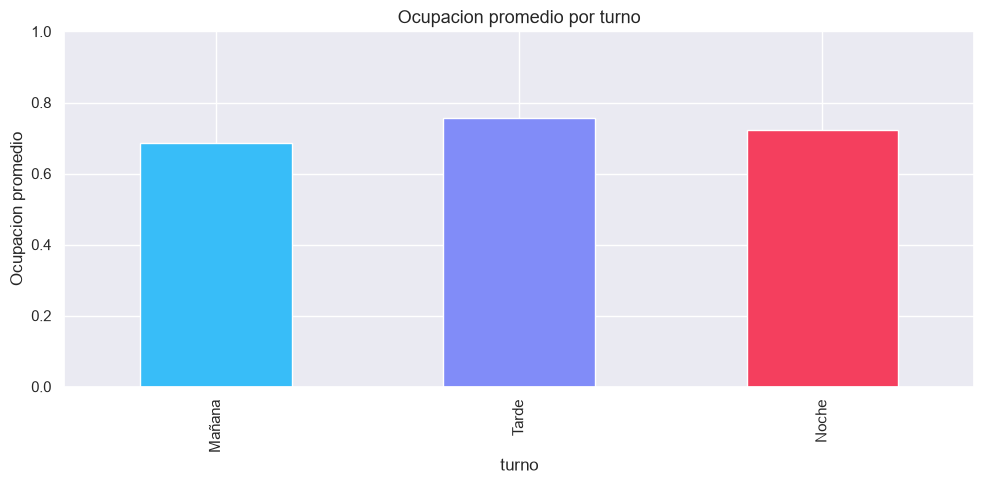

In [4]:
turno = df.groupby("turno")["tasa_ocupacion"].mean().reindex(["Mañana","Tarde","Noche"])
ax = turno.plot(kind="bar", color=["#38bdf8","#818cf8","#f43f5e"])
ax.set_title("Ocupacion promedio por turno")
ax.set_ylabel("Ocupacion promedio")
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

## 3. Pabellones criticos
Filtramos ocupacion >= 95% y sumamos pacientes en espera acumulados.

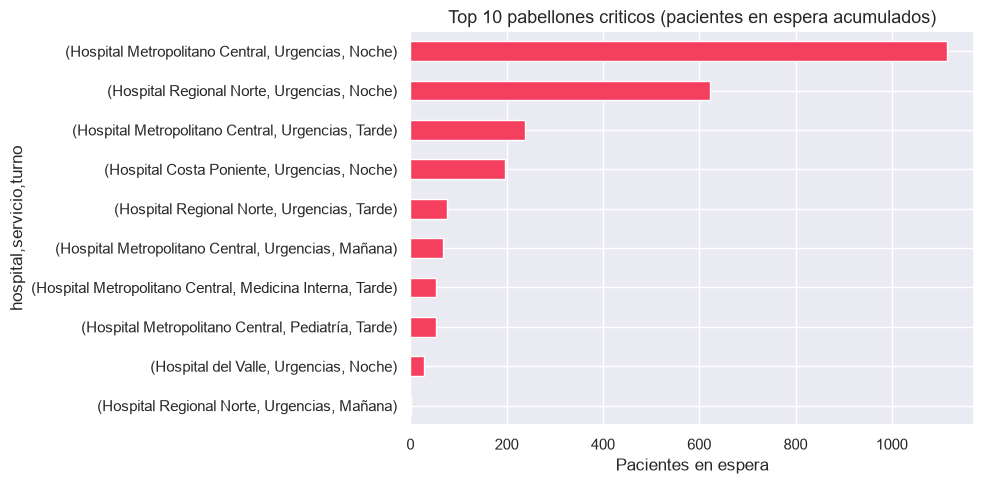

hospital                        servicio   turno
Hospital Metropolitano Central  Urgencias  Noche    1115
Hospital Regional Norte         Urgencias  Noche     622
Hospital Metropolitano Central  Urgencias  Tarde     238
Name: pacientes_en_espera, dtype: int64

In [5]:
critico = df[df.tasa_ocupacion >= 0.95]
top = (critico.groupby(["hospital","servicio","turno"])["pacientes_en_espera"]
       .sum().sort_values(ascending=False).head(10))
ax = top.sort_values().plot(kind="barh", color="#f43f5e")
ax.set_title("Top 10 pabellones criticos (pacientes en espera acumulados)")
ax.set_xlabel("Pacientes en espera")
plt.tight_layout(); plt.show()
top.head(3)

## 4. Efecto campana de invierno (mayo-agosto)

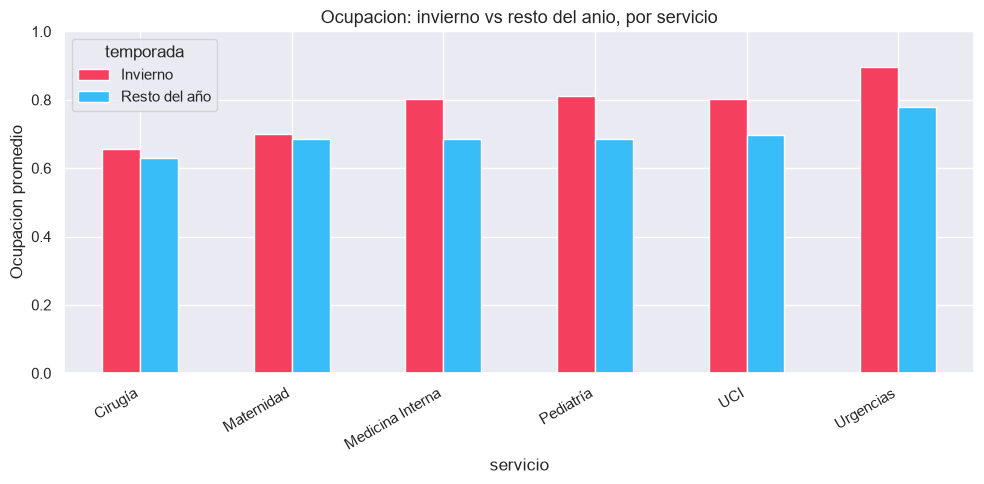

temporada,Invierno,Resto del año
servicio,,
Cirugía,0.655705,0.628423
Maternidad,0.700963,0.685689
Medicina Interna,0.802485,0.685225
Pediatría,0.810113,0.685541
UCI,0.801476,0.697681
Urgencias,0.895411,0.777775


In [6]:
df["temporada"] = df.fecha.dt.month.between(5, 8).map({True:"Invierno", False:"Resto del año"})
comp = df.groupby(["servicio","temporada"])["tasa_ocupacion"].mean().unstack()
ax = comp.plot(kind="bar", color={"Invierno":"#f43f5e","Resto del año":"#38bdf8"})
ax.set_title("Ocupacion: invierno vs resto del anio, por servicio")
ax.set_ylabel("Ocupacion promedio"); ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
comp

## 5. Conclusiones de negocio

- **Urgencias en turno noche** es el cuello de botella estructural: mayor ocupacion y espera acumulada.
- La **campana de invierno** eleva la ocupacion en los servicios respiratorios y urgencias: conviene anticipar refuerzo de camillas y personal mayo-agosto.
- **Accion recomendada:** reasignar capacidad y evaluar derivacion entre hospitales con menor ocupacion hacia los saturados.